<a href="https://colab.research.google.com/github/Attri-Niharika/CEI-Assignments/blob/main/week4_Niharika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

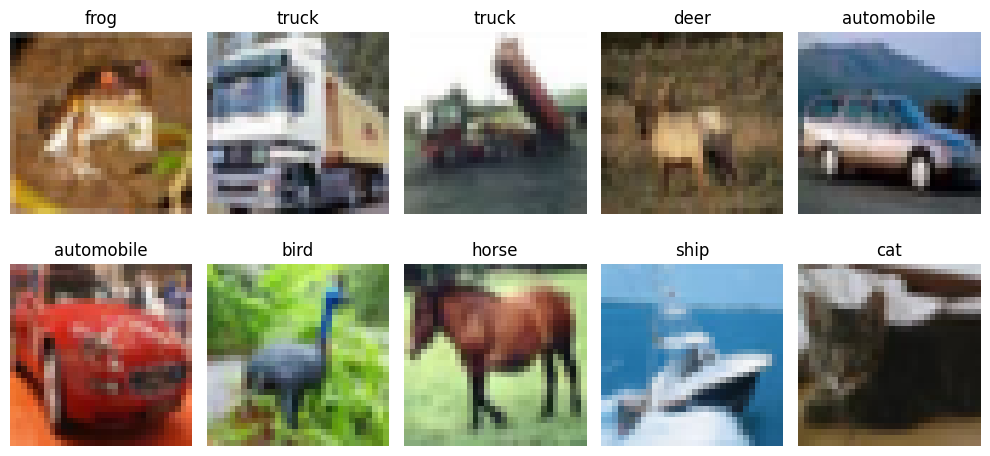

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2694 - loss: 1.9961 - val_accuracy: 0.3336 - val_loss: 1.8514
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3191 - loss: 1.8661 - val_accuracy: 0.3520 - val_loss: 1.8093
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3414 - loss: 1.8140 - val_accuracy: 0.3904 - val_loss: 1.7288
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3579 - loss: 1.7716 - val_accuracy: 0.3912 - val_loss: 1.7101
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3652 - loss: 1.7498 - val_accuracy: 0.4038 - val_loss: 1.7009
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3742 - loss: 1.7250 - val_accuracy: 0.4278 - val_loss: 1.6587
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3831 - loss: 1.7052 - val_accuracy: 0.4144 - val_loss: 1.6486
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3898 - loss: 1.6831 - val_accuracy: 0.

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4257 - loss: 1.6317
ANN Test Accuracy: 0.42570000886917114


## 📈 Task 1: Increase ANN Layers and Observe Performance

In [8]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ANN Model V2 with more layers...")
ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Training ANN Model V2 with more layers...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2546 - loss: 2.0194 - val_accuracy: 0.3212 - val_loss: 1.8576
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3122 - loss: 1.8744 - val_accuracy: 0.3652 - val_loss: 1.7751
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3259 - loss: 1.8366 - val_accuracy: 0.3796 - val_loss: 1.7627
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3519 - loss: 1.7829 - val_accuracy: 0.3920 - val_loss: 1.7215
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3545 - loss: 1.7683 - val_accuracy: 0.3672 - val_loss: 1.7325
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3633 - loss: 1.7489 - val_accuracy: 0.4104 - val_loss: 1.6854
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3732 - loss: 1.7251 - val_accuracy: 0.4108 - val_loss: 1.6827
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accurac

In [9]:
ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test)
print("ANN Model V2 Test Accuracy:", ann_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4320 - loss: 1.6332
ANN Model V2 Test Accuracy: 0.4320000112056732


### Comparison with Original ANN Model

Let's compare the performance of the original ANN model with the new ANN model with increased layers.

In [10]:
comparison_v2 = pd.DataFrame({
    "Model": ["ANN Original", "ANN Increased Layers"],
    "Test Accuracy": [ann_test_acc, ann_test_acc_v2]
})
display(comparison_v2)

,Model,Test Accuracy
0,ANN Original,0.4257
1,ANN Increased Layers,0.4320


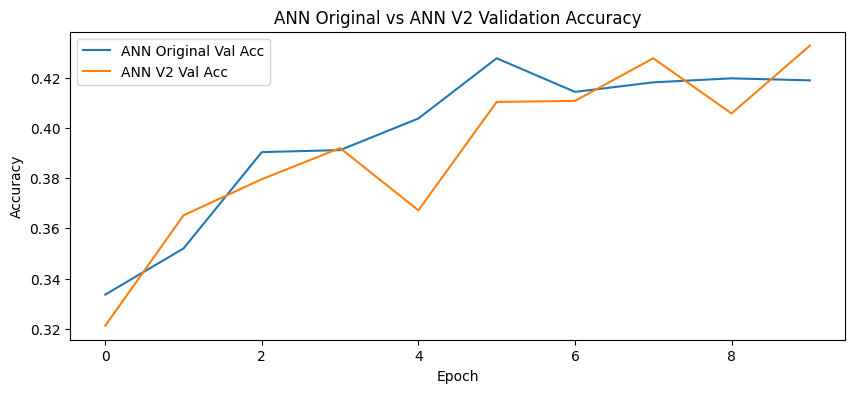

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Original vs ANN V2 Validation Accuracy")
plt.legend()
plt.show()

## 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [12]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4756 - loss: 1.4692 - val_accuracy: 0.5222 - val_loss: 1.3710
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6075 - loss: 1.1129 - val_accuracy: 0.6442 - val_loss: 1.0094
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6683 - loss: 0.9444 - val_accuracy: 0.6224 - val_loss: 1.1636
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7123 - loss: 0.8283 - val_accuracy: 0.6706 - val_loss: 1.0049
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7406 - loss: 0.7364 - val_accuracy: 0.7038 - val_loss: 0.8451
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7702 - loss: 0.6582 - val_accuracy: 0.7150 - val_loss: 0.8564
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7914 - loss: 0.5903 - val_accuracy: 0.6576 - val_loss: 1.0218
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8108 - loss: 0.5295 - val_accuracy: 

In [13]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7199 - loss: 0.9057
CNN Test Accuracy: 0.7199000120162964


## 📈 Compare Learning Curves

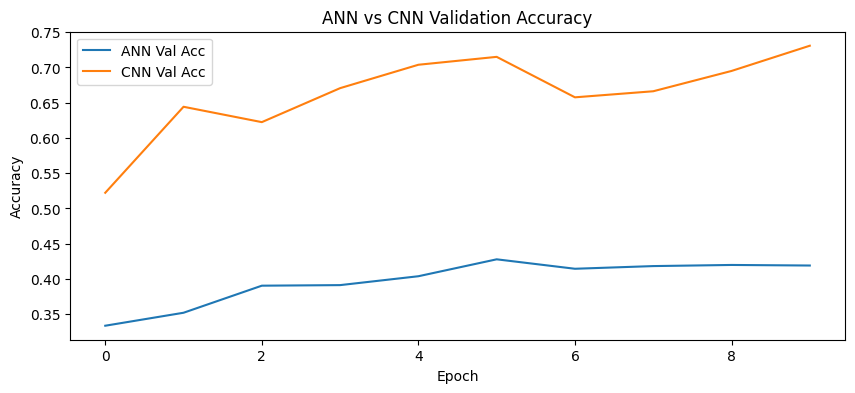

In [14]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

## 📈 Task 2: Change CNN filters from 32→64→128

In [16]:
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V2 with increased filters...")
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Training CNN Model V2 with increased filters...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.4414 - loss: 1.5665 - val_accuracy: 0.4906 - val_loss: 1.4599
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5965 - loss: 1.1629 - val_accuracy: 0.6336 - val_loss: 1.0575
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6565 - loss: 0.9880 - val_accuracy: 0.6522 - val_loss: 1.0070
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7086 - loss: 0.8386 - val_accuracy: 0.6496 - val_loss: 1.0466
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7419 - loss: 0.7404 - val_accuracy: 0.6796 - val_loss: 1.0338
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7746 - loss: 0.6480 - val_accuracy: 0.5782 - val_loss: 1.5032
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8022 - loss: 0.5651 - val_accuracy: 0.6398 - val_loss: 1.1093
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - 

In [17]:
cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test)
print("CNN Model V2 Test Accuracy:", cnn_test_acc_v2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7112 - loss: 1.0915
CNN Model V2 Test Accuracy: 0.7111999988555908


### Comparison with Original CNN Model

Let's compare the performance of the original CNN model with the new CNN model with increased filters.

In [18]:
comparison_cnn_v2 = pd.DataFrame({
    "Model": ["CNN Original", "CNN Increased Filters"],
    "Test Accuracy": [cnn_test_acc, cnn_test_acc_v2]
})
display(comparison_cnn_v2)

,Model,Test Accuracy
0,CNN Original,0.7199
1,CNN Increased Filters,0.7112


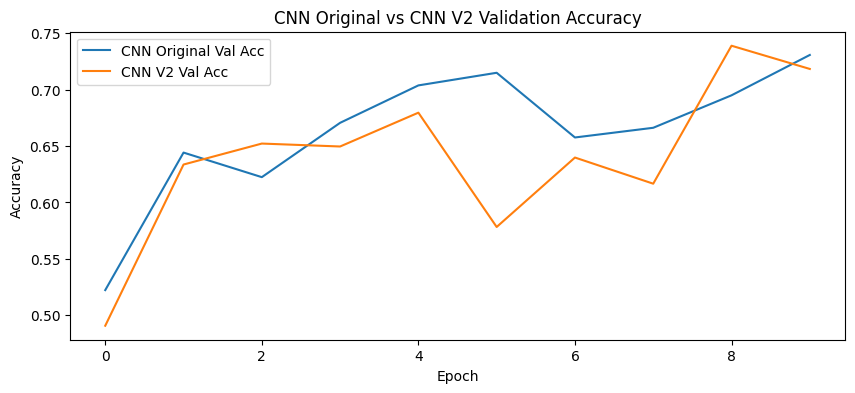

In [19]:
plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Original vs CNN V2 Validation Accuracy")
plt.legend()
plt.show()

## 📈 Task 3: Increase Epochs to 20 with EarlyStopping and Data Augmentation

In [20]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Data Augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Create a new CNN model incorporating data augmentation and slightly modified architecture for improved performance
cnn_model_v3 = models.Sequential([
    data_augmentation,
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CNN Model V3 with 20 epochs, EarlyStopping, and Data Augmentation...")
cnn_history_v3 = cnn_model_v3.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN Model V3 with 20 epochs, EarlyStopping, and Data Augmentation...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - accuracy: 0.3764 - loss: 1.7297 - val_accuracy: 0.4686 - val_loss: 1.5557
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4882 - loss: 1.4457 - val_accuracy: 0.5202 - val_loss: 1.3309
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5394 - loss: 1.3194 - val_accuracy: 0.5430 - val_loss: 1.4111
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5720 - loss: 1.2293 - val_accuracy: 0.6416 - val_loss: 1.0217
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5972 - loss: 1.1594 - val_accuracy: 0.6676 - val_loss: 0.9543
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6200 - loss: 1.1001 - val_accuracy: 0.6710 - val_loss: 0.9659
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6352 - loss: 1.0603 - val_accuracy: 0.6388 - val_loss: 1.0689
Epoch 8/20
7

In [21]:
cnn_test_loss_v3, cnn_test_acc_v3 = cnn_model_v3.evaluate(x_test_norm, y_test)
print("CNN Model V3 Test Accuracy (20 epochs, EarlyStopping, Data Augmentation):", cnn_test_acc_v3)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7364 - loss: 0.7932
CNN Model V3 Test Accuracy (20 epochs, EarlyStopping, Data Augmentation): 0.7364000082015991


### Final Comparison of All Models

Let's compare the performance of all models implemented so far.

In [22]:
final_comparison = pd.DataFrame({
    "Model": ["ANN Original", "ANN Increased Layers", "CNN Original", "CNN Increased Filters", "CNN with Augmentation, ES, and 20 Epochs"],
    "Test Accuracy": [ann_test_acc, ann_test_acc_v2, cnn_test_acc, cnn_test_acc_v2, cnn_test_acc_v3]
})
display(final_comparison.sort_values(by="Test Accuracy", ascending=False))

,Model,Test Accuracy
4,"CNN with Augmentation, ES, and 20 Epochs",0.7364
2,CNN Original,0.7199
3,CNN Increased Filters,0.7112
1,ANN Increased Layers,0.4320
0,ANN Original,0.4257


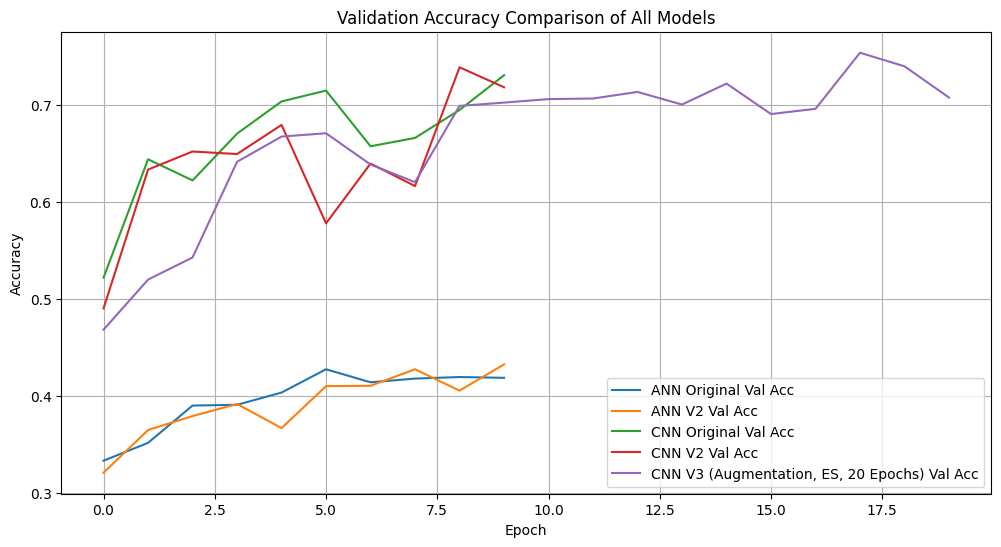

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 Val Acc')
plt.plot(cnn_history_v3.history['val_accuracy'], label='CNN V3 (Augmentation, ES, 20 Epochs) Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison of All Models")
plt.legend()
plt.grid(True)
plt.show()

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [24]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4680 - loss: 1.4884 - val_accuracy: 0.4876 - val_loss: 1.4936
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6038 - loss: 1.1341 - val_accuracy: 0.5238 - val_loss: 1.3357
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6665 - loss: 0.9550 - val_accuracy: 0.6310 - val_loss: 1.0458
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7095 - loss: 0.8315 - val_accuracy: 0.5358 - val_loss: 1.5750
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7373 - loss: 0.7431 - val_accuracy: 0.6512 - val_loss: 1.0201
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7654 - loss: 0.6659 - val_accuracy: 0.6900 - val_loss: 0.8968
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7923 - loss: 0.5878 - val_accuracy: 0.7272 - val_loss: 0.8303
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8146 - loss: 0.5227 - val_accuracy: 

In [25]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7188 - loss: 0.9382
CNN Test Accuracy: 0.7188000082969666


## 📈 Compare Learning Curves

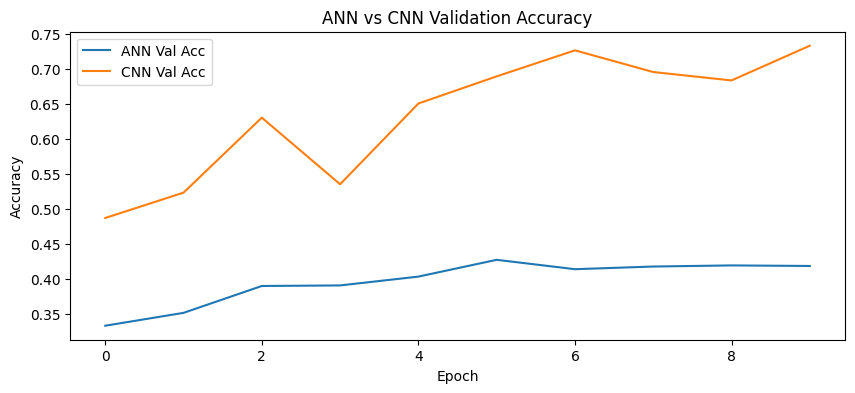

In [26]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [27]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [28]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4257
1,CNN,0.7188


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**